# Practical exercises

 - The aim of this notebook is to guide you through a few exercises in machine-learning for image processing.
 - We will work through some simple examples of discriminative and generative AI concepts, using the following core packages:
     - [`PyTorch`](https://docs.pytorch.org/docs/stable/index.html): Now the industry standard for developing deep neural networks in Python.
     - [`MONAI`](https://github.com/Project-MONAI/MONAI): A suite of tools aimed at improving deep-learning within medical imaging applications, including pre-processing, augmentation and multi-GPU support. Works directly with PyTorch.
     - [`scikit-learn`](https://scikit-learn.org/): Provides core machine-learning concepts within Python (largely non deep-learning based).
 - The examples we works through are aimed to provide you with some exposure to the different techniques that are available and how they may be used in medical imaging. They do not necessarily represent the state of the art as training deep-learning models requires both large __computational resources__ and __time__.
 - However, by the end we hope these excercises will help clarify the underlying technology that is ubiquitous in state-of-the-art AI techniques.

 - You can run this notebook within Collab using the following link [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mdblackledge/theoryofimaging2/blob/main/notes.ipynb)

     https://colab.research.google.com/github/mdblackledge/theoryofimaging2/blob/main/notes.ipynb

In [1]:
!pip install monai  # Not installed by default on Colab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 39.4 MB/s eta 0:00:00


# __1. The dataset__
 - In these exercises, we will make use of a simple and free dataset that is available on [_kaggle_](https://www.kaggle.com/) comprising of images of Lego bricks.
 - First, let's download the dataset and look at examples for each of the black groups.

100%|██████████| 1.00G/1.00G [00:48<00:00, 22.1MB/s]

Extracting files...


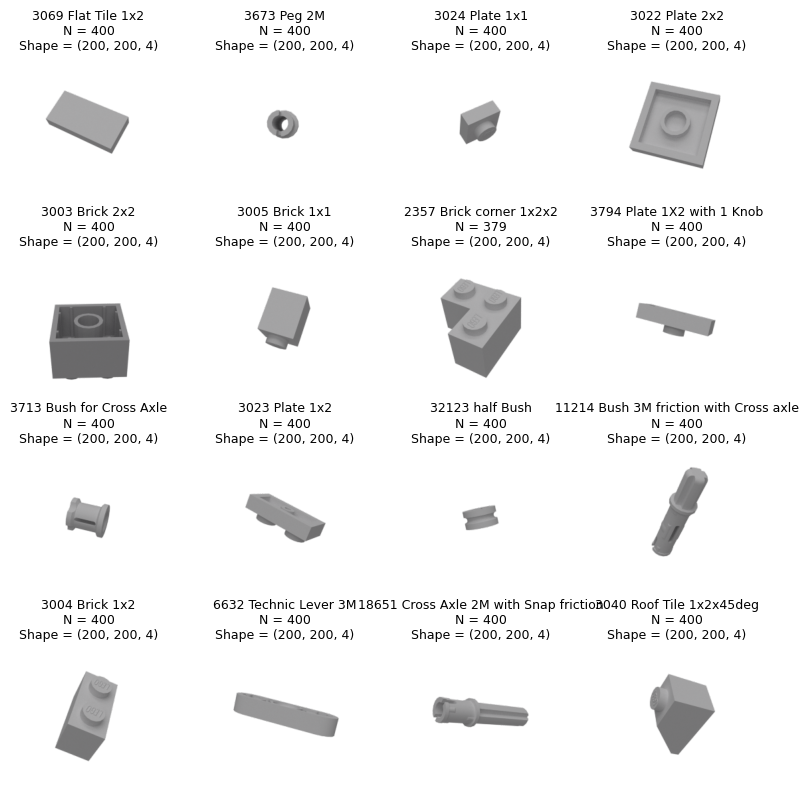

In [2]:
# @title
import os

import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import skimage

# Download latest version
clean_data_path = kagglehub.dataset_download("joosthazelzet/lego-brick-images")\
                    + "/LEGO brick images v1"

# Random seed
np.random.seed(2026)

# Read random files and display
f, ax = plt.subplots(4, 4, figsize = (8, 8))
ax = ax.ravel()
for i in range(16):

    # Randomly select a block type and image
    block_group_dir = clean_data_path + "/" + os.listdir(clean_data_path)[i]
    block_file = block_group_dir + "/" + np.random.choice(os.listdir(block_group_dir))

    # Display
    arr = skimage.io.imread(block_file)
    ax[i].imshow(arr)
    ax[i].set_title(block_file.split("/")[-2] + "\n"\
                    + f"N = {len(os.listdir(block_group_dir))}" + "\n"\
                    + f"Shape = {arr.shape}", fontsize = 9.)
    ax[i].axis("off")

plt.tight_layout()
plt.show()

 - As we saw in the lectures, medical images are less than when perfect compared with these examples.
 - They are affected by noise, blurring (_partial volume effects_), and artifacts.
 - We will create a function to artificially degrade these images, whilst also turning them into more _medical-like_ images (single channel with background being zero).  

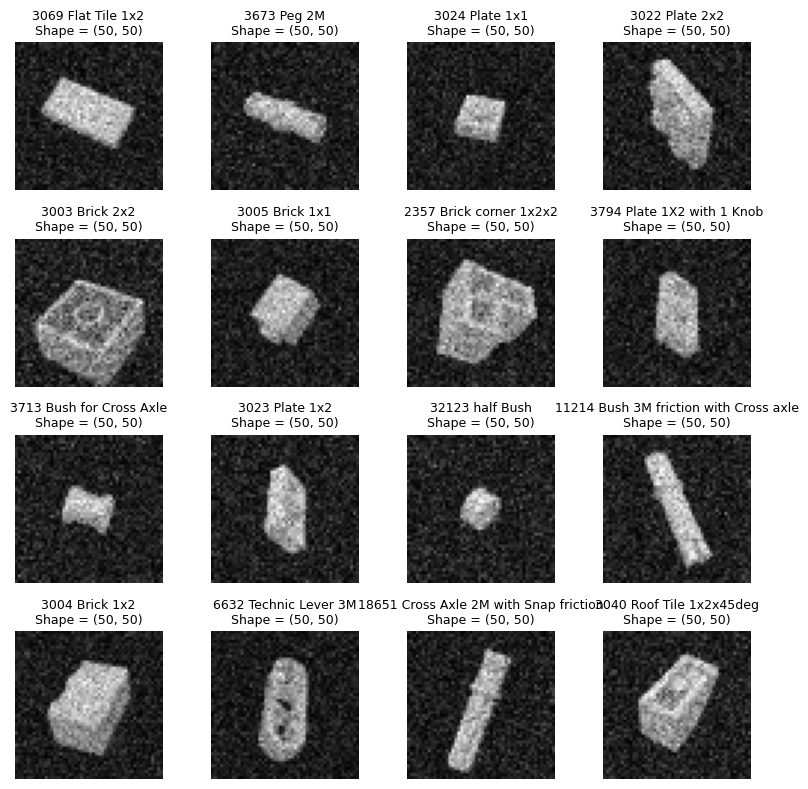

In [3]:
from skimage.transform import resize

# Global parameters for the experiments
SHAPE = (50, 50)
SNR = 12.0

def degrade_loego_image(arr, snr = 30.0, shape = (50, 50)):
    """ Degrade the quality of an image of a Lego brick.

    Parameters
    ----------
    arr : numpy.ndarray
        The input image.

    snr : float, optional
        The signal-to-noise ratio.

    shape : (int, int), optional
        The output array shape.

    Returns
    -------
    numpy.ndarray
        The degraded image.
    """
    arr_bw = arr[..., 0].astype("float32")  # Just the first channel
    arr_bw = resize(
        arr_bw,
        shape,
        order=1,               # 1 = bilinear
        mode='reflect',
        anti_aliasing=True,
        preserve_range=True    # keeps original value range
    )

    # We use Rician noise to ensure non-negative values (as in medical imaging)
    sigma = 255.0 / snr
    arr_noisy = np.clip(np.sqrt((arr_bw + np.random.randn(*arr_bw.shape) * sigma) ** 2 +\
                                (np.random.randn(*arr_bw.shape) * sigma) ** 2), 0, 255)
    return arr_noisy.astype("uint8")


# Random seed
np.random.seed(2026)

f, ax = plt.subplots(4, 4, figsize = (8, 8))
ax = ax.ravel()
for i in range(16):

    # Randomly select a block type and image
    block_group_dir = clean_data_path + "/" + os.listdir(clean_data_path)[i]
    block_file = block_group_dir + "/" + np.random.choice(os.listdir(block_group_dir))

    # Degrade the image.
    arr = skimage.io.imread(block_file)
    arr_noisy = degrade_loego_image(arr, snr=SNR, shape=SHAPE)

    # Display
    ax[i].imshow(arr_noisy, cmap = "gray")
    ax[i].set_title(block_file.split("/")[-2] + "\n"\
                    + f"Shape = {arr_noisy.shape}", fontsize = 9.)
    ax[i].axis("off")

plt.tight_layout()
plt.show()

 - We will now store these degraded images seperately in a seperate file-system.
 - Files are stored in the location:
    
    `input_images_dir = "/content/input_images"`
    
 - This emulates the data you might have in real life.

In [4]:
from tqdm import tqdm

input_images_dir = "/content/input_images"

if not os.path.exists(input_images_dir):
    for block_group_dir in tqdm(os.listdir(clean_data_path), desc = "Resampling images"):
        block_group_path = clean_data_path + "/" + block_group_dir
        for block_file in os.listdir(block_group_path):
            block_path = block_group_path + "/" + block_file
            arr = skimage.io.imread(block_path)
            arr_noisy = degrade_loego_image(arr, snr=SNR, shape=SHAPE)
            os.makedirs(input_images_dir + "/" + block_group_dir, exist_ok=True)
            skimage.io.imsave(input_images_dir + "/" + block_group_dir + "/" + block_file, arr_noisy)

Resampling images: 100%|██████████| 16/16 [00:29<00:00,  1.84s/it]


# __2. Binary classifier__
 - As a backbone for classification tasks, we're going to build on a classic neural network architecture __LeNet__.
 - This technology revolusionized the field of AI and has been instrumental in bringing AI to the forefront of daily life.
 - Traditionally, this architecture was developed for 10-class classification tasks (identification of hand-drawn numerical digits).
 - We will start with a simple binary classifer.

 <img src="https://raw.githubusercontent.com/mdblackledge/theoryofimaging2/main/workshop/figures/lenet.png?cache_bust=20260216" width=80%>

## Data splitting

 - First, we load the images from two block types, each representing a different class.
 - We retain 20% of the images for later testing of the algorithm.

In [5]:
import random

from sklearn.model_selection import train_test_split


label_0 = "3022 Plate 2x2"
label_1 = "3005 Brick 1x1"

# Loading the datasets as dictionaries is important for MONAI data reading.
label_0_files = [
    {"image": os.path.join(input_images_dir, label_0, fname), "label": 0}
    for fname in os.listdir(os.path.join(input_images_dir, label_0))
    if fname.endswith(".png")
]
label_1_files = [
    {"image": os.path.join(input_images_dir, label_1, fname), "label": 1}
    for fname in os.listdir(os.path.join(input_images_dir, label_1))
    if fname.endswith(".png")
]

# Concatenate into a single list
files = label_0_files + label_1_files

# Split into train/test (80/20)
test_fraction = 0.2

files_train, files_test = train_test_split(
    files,
    test_size=test_fraction,
    stratify=[f["label"] for f in files],
    random_state=2026,
)

# Further hold back some of the training data for validation
files_train, files_val = train_test_split(
    files_train,
    test_size=test_fraction,
    stratify=[f["label"] for f in files_train],
    random_state=2026,
)

## Data preprocessing and augmentation
 - __Data preprocessing__ ensures that data are standardized before being used for model training or inference.
 - These transforms are deterministic and applied to both training data and during algorithm inference.
 - This includes:
    - Shape standardization: Ensuring that all input images have identical spatial dimensions before being passed to the model.
    - Intensity normalization: Neural networks typically perform better when inputs are normalized, often with values scaled to a consistent range that may include negative values.  
    - Data type standardization: Ensuring inputs are converted to a consistent numerical type (e.g., `float32`) before being passed to the network.
    - Channel formatting: Making sure data follow a consistent shape convention (e.g., channel-first format (`C, H, W`) for `torch`).
    - Label formatting: Converting labels into the required form (e.g., integer class indices, one-hot encoding, or tensor format).
    - Rescaling or cropping to region of interest: Removing irrelevant background or padding so that the model focuses on meaningful content.
    - Conversion to `torch` tensor format.
 <br>

 - __Data augmentation__ is a highly effective technique for reducing model overfitting.
 - During training, it applies transformations to the data, expanding the distribution of samples seen during optimization.
 - Transforms should emulate what is likely to be encountered in future datasets.
 - Typically applied to training data only.
 - Examples in imaging applications include:
    - Translational shifts
    - Rotations
    - Image flips
    - Addition of random noise
    - Non-linear deformations
    - Signal scaling
    - Zooming
    - Padding/cropping
 <br>

 - `MONAI` provides effective pipelines for both data preprocessing and augmentation.
 - The list of available operations can be found here: https://monai.readthedocs.io/en/1.4.0/transforms.html#vanilla-transforms

In [6]:
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ScaleIntensityd,
    ResizeD,
    RandFlipd,
    RandGaussianNoised,
    Rand2DElasticd,
    ToTensord,
)

transforms_train = Compose([
    LoadImaged(keys=["image"]), # Preprocessing
    EnsureChannelFirstd(keys=["image"]), # Preprocessing
    ScaleIntensityd(keys=["image"]), # Preprocessing
    ResizeD(keys=["image"], spatial_size=(50, 50)), # Preprocessing
    RandFlipd(keys=["image"], prob=0.5),  # Augmentation
    RandGaussianNoised(keys=["image"], prob=0.5, mean=0, std=0.1),  # Augmentation
    Rand2DElasticd(keys=["image"], prob=0.5, spacing=(5, 5), magnitude_range=(0, 0.2)),  # Augmentation
    ToTensord(keys=["image"]), # Preprocessing
])

# Note that augmentaiotn is NOT applied during inference.
transforms_inference = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    ScaleIntensityd(keys=["image"]),
    ResizeD(keys=["image"], spatial_size=(50, 50)),
    ToTensord(keys=["image"]),
])

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


 - Next, we load the data into efficient datasets for model training.
 - We use MONAI for this purpose, specifically the `CacheDataset` class.
 - `CacheDataset` stores data in memory after it has been processed once, so it does not need to repeatedly load and preprocess the same files from disk.
 - This significantly reduces disk I/O and improves training speed, particularly for large-scale image processing tasks.
 - Deterministic preprocessing steps (e.g., intensity normalization, resizing, reorientation) are cached, while random data augmentations are still applied on-the-fly during each training epoch.
 - This ensures both efficiency and proper augmentation behavior.
 - Because processed samples are stored in RAM, memory usage increases. Sufficient system memory is required, especially when working with large images or 3D volumes.

Loading dataset: 100%|██████████| 128/128 [00:00<00:00, 350.80it/s]


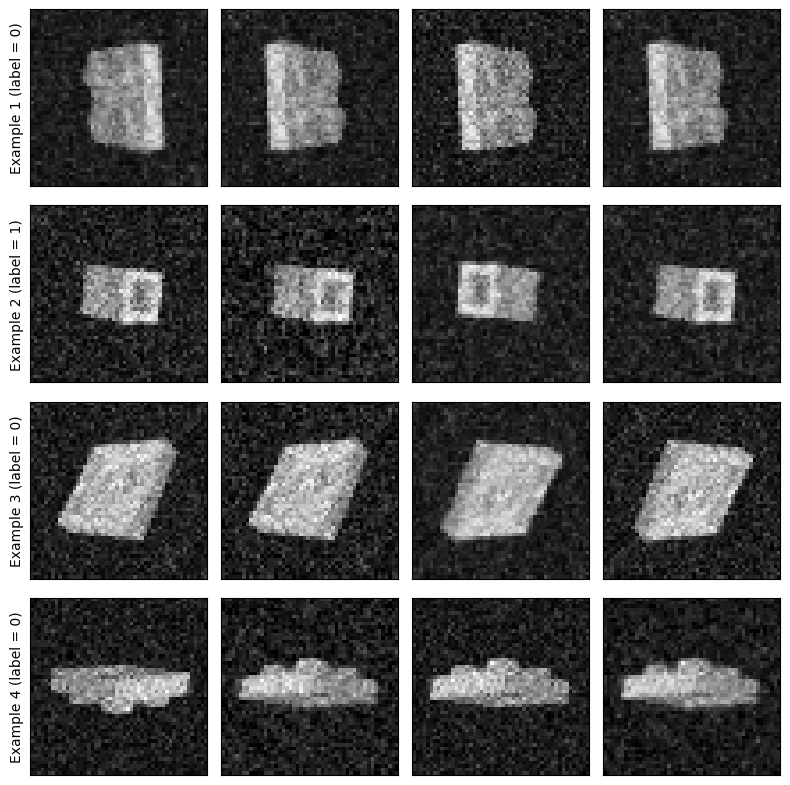

In [7]:
from monai.data import CacheDataset

train_ds = CacheDataset(
    data=files_train,
    transform=transforms_train,
    cache_rate=1.0,      # cache all data
    num_workers=4        # workers used during caching
)

# for validation, we do not use augmentation.
val_ds = CacheDataset(
    data=files_val,
    transform=transforms_inference,
    cache_rate=1.0,      # cache all data
    num_workers=4        # workers used during caching
)

# Lets plot some examples
f, ax = plt.subplots(4, 4, figsize = (8, 8))
ax = ax.ravel()
for i in range(16):
    if i % 4 == 0:
        ax[i].set_ylabel(f"Example {int(i / 4) + 1} (label = {train_ds[int(i / 4)]["label"]})")
    ax[i].imshow(train_ds[int(i / 4)]["image"][0], cmap = "gray", clim = (0, 1))
    ax[i].set_xticks([]), ax[i].set_yticks([])

plt.tight_layout()
plt.show()

### Execise 1
 - Try modifying the data augmentation pipeline parameters (2 cells prior) and review the results (previous cell).
 - Use the MONAI documentation to add random translations during augmentation
        
    _Hint_: This is achievable via the `RandAffined` function
 - Decide which augmentation combination you think most appropriate for moving forward.

## Classification model
 - The cell below defines the binary classification model, designed on LeNet.
 - One slight modification we have made is to allow the model to predict the penultimate layer seperately via the `featurize` method.
 - This does not make any difference to the final result, it just allows us to visualize this layer to see what is happening.

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LeNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)

        self.fc1 = nn.Linear(16 * 9 * 9, 120) # Assumes input size 50x50
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 2)
        self.classifier = nn.Linear(2, num_classes)

    def featurize(self, x):
        x = F.relu(self.conv1(x))  # conv1 -> ReLU activation
        x = F.max_pool2d(x, 2)     # Max pooling with 2x2 kernel
        x = F.relu(self.conv2(x))  # conv2 -> ReLU activation
        x = F.max_pool2d(x, 2)     # Max pooling with 2x2 kernel
        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)            # 2D embedding (for visualization)
        return x

    def forward(self, x):
        x = self.featurize(x)
        x = self.classifier(x)   # raw logits
        return x

    def classify(self, x):
        logits = self.forward(x)
        probs = torch.softmax(logits, dim=1)
        return probs

## Model training
 - Now we will train the model from our (augmented) training data.
 - `torch` is particularly good for this. It allows us to define the training schedule with a lot of flexibility.
 - We use an approach called _back propagation_ that allows us to minimize a _loss_ function that defines how well our model is working.
 - For binary classification tasks we generally use _binary cross entropy_ as the loss.

    $$
        L_{\theta}(y, \widehat{y}) = \frac{1}{N}\sum\limits_{i=1}^{N}y_{i}\ln\widehat{y}_{i} + (1 - y _{i})\ln(1 - \widehat{y} _{i})
    $$
    
    where $y_{i} \in $ {0,1} is the true label, and $\widehat{y}_{i} \in (0, 1)$ is the (soft) prediction from the model with parameters $\theta$.

 - When $\widehat{y}_{i} = y_{i}$, then $L=0$.

$ $

In [12]:
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm  # Used for monitoring progress as a progress bar

# Some training hyper-parameters
learning_rate = 1e-3
num_epochs = 100
batch_size = 40
device = "cuda"

# Create an instance of the model to be trained
model = LeNet(num_classes=2)
model.to(device)

# Data loaders will ensure efficient batching of data during training and validation
train_loader = DataLoader(train_ds,
                          batch_size=batch_size,
                          shuffle=True,
                          num_workers=4)
val_loader = DataLoader(val_ds,
                        batch_size=batch_size,
                        shuffle=True,
                        num_workers=4)

# Binary cross entropy loss
criterion = nn.CrossEntropyLoss()

# This keeps track of all parameter gradients that are used to improve
# the model parameters for each training epoch
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

pbar = tqdm(range(num_epochs))
for epoch in pbar:

    # -------------------
    # TRAINING
    # -------------------

    # Tell the model it is in training mode.
    model.train()

    for batch in train_loader:

        # Get data for the current batch
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        # Clear gradients from previous batch
        optimizer.zero_grad()

        # Predict based on current parameters
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Determine the gradients and back-propagate.
        loss.backward()
        optimizer.step()


    # -------------------
    # VALIDATION
    # -------------------

    # Put model into evaluation mode
    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            images = batch["image"].to(device)
            labels = batch["label"].to(device)

            outputs = model(images)
            val_loss = criterion(outputs, labels)
            pbar.set_description(f"Val Loss: {loss.item():.4f} - Val Loss: {val_loss.item():.4f}")



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Val Loss: 0.0000 - Val Loss: 0.0000: 100%|██████████| 100/100 [03:06<00:00,  1.87s/it]


In [ ]:
for